# Train trVAE model and generate trVAE features for the integrated fiber dataset
A new trVAE embedding had to be created, as the fibers in this dataset have counts for both the 480 and 5000 genes. \
I also tested generating a trVAE embedding with 20 features (instead of the default 10) to see if that would create an embedding with more 'structure' in the UMAP, to better be able to define fiber clusters in this embedding space. This was not the case, so I dropped this idea. 

In [1]:
import numpy as np
import scanpy as sc
import anndata as ad
from pathlib import Path
import matplotlib.pyplot as plt
import os
import pandas as pd
import scvi
import scarches as sca
import torch
from scipy.sparse import issparse

/exports/archive/hg-groep-spitali/Students/Caro/conda/envs/scarches/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /exports/archive/hg-groep-spitali/Students/Caro/conda/envs/scarches/lib/python3.10/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
/exports/archive/hg-groep-spitali/Students/Caro/conda/envs/scarches/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
 captum (see https://github.com/pytorch/captum).


In [2]:
cd ../../data/IBM

/exports/archive/hg-groep-spitali/Students/Caro/data/IBM


/exports/archive/hg-groep-spitali/Students/Caro/conda/envs/scarches/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
trvae_epochs = 100

early_stopping_kwargs = {
    "early_stopping_metric": "val_unweighted_loss",
    "threshold": 0,
    "patience": 20,
    "reduce_lr": True,
    "lr_patience": 13,
    "lr_factor": 0.1,
}

## Train and generate trVAE (full integrated genes dataset, no gene filtering)

In [ ]:
adata = sc.read_h5ad('integrated_480_5000/adata_integrated_480_5000_fibers_preprocessed_unfiltered.h5ad')


In [ ]:
#ensure raw count data is in .X layer (needed when using 'nb' loss, the default)
adata.X = adata.layers['integrated_raw'].copy().astype('float32')

trvae = sca.models.TRVAE(
    adata=adata,
    condition_key='sample_id_new',
    conditions=['sample1', 'sample2', 'sample3', 'sample4','sample5','sample6'],
    hidden_layer_sizes=[128, 128],
)

trvae.train(
    n_epochs=trvae_epochs,
    alpha_epoch_anneal=200,
    early_stopping_kwargs=early_stopping_kwargs
)

trvae.save('trVAE_models/trvae_model_integrated_480_5000_unfiltered', overwrite=True)

In [ ]:
# Optional: load saved model
trvae = sca.models.TRVAE.load_query_data(adata=adata, reference_model='trVAE_models/trvae_model_integrated_480_5000_unfiltered/')

In [ ]:
# X: raw gene counts (in .X layer)
X = adata.X
if issparse(X):
    X = X.toarray()

X = X.astype("float32")

# C: condition for batch correction (sample id)
C = adata.obs["sample_id_new"].values 

# Z: generated trVAE features using trained model
Z = trvae.get_latent(X, C)
adata.obsm["X_trVAE"] = Z

In [ ]:
# Save adata
adata.write_h5ad("integrated_480_5000/adata_integrated_480_5000_fibers_trvae_unfiltered.h5ad")

## Train and generate trVAE (filtered integrated genes dataset, using only genes that are expressed in >1% of the fibers)

In [3]:
### Using only genes that are expressed in >1% of fibers
adata = sc.read_h5ad('integrated_480_5000/adata_integrated_480_5000_fibers_preprocessed_filtered.h5ad')

In [ ]:
#ensure raw count data is in .X layer (needed when using 'nb' loss, the default)
adata.X = adata.layers['integrated_raw'].copy().astype('float32')

trvae = sca.models.TRVAE(
    adata=adata,
    condition_key='sample_id_new',
    conditions=['sample1', 'sample2', 'sample3', 'sample4','sample5','sample6'],
    hidden_layer_sizes=[128, 128],
)

trvae.train(
    n_epochs=trvae_epochs,
    alpha_epoch_anneal=200,
    early_stopping_kwargs=early_stopping_kwargs
)

trvae.save('trVAE_models/trvae_model_integrated_480_5000_filtered', overwrite=True)

In [ ]:
# Optional: load saved model
trvae = sca.models.TRVAE.load_query_data(adata=adata, reference_model='trVAE_models/trvae_model_integrated_480_5000_filtered/')

In [ ]:
# X: raw gene counts (in .X layer)
X = adata.X
if issparse(X):
    X = X.toarray()

X = X.astype("float32")

# C: condition for batch correction (sample id)
C = adata.obs["sample_id_new"].values 

# Z: generated trVAE features using trained model
Z = trvae.get_latent(X, C)
adata.obsm["X_trVAE"] = Z

In [ ]:
# Save adata
adata.write_h5ad("integrated_480_5000/adata_integrated_480_5000_fibers_trvae_filtered.h5ad")

## Train and generate trVAE with 20 features (filtered integrated genes dataset)
I wanted to see if generating 20 trVAE features (instead of the default 10) would create an embedding with more 'structure' in the UMAP, to better be able to define fiber clusters in this embedding space. This was not the case, so I dropped this idea.

In [ ]:
### Using only genes that are expressed in >1% of fibers
adata = sc.read_h5ad('integrated_480_5000/adata_integrated_480_5000_fibers_preprocessed_filtered.h5ad')

In [5]:
# Ensure raw count data is in .X layer (needed when using 'nb' loss, the default)
adata.X = adata.layers['integrated_raw'].copy().astype('float32')

# setup trVAE model with 20 features (default=10)
trvae = sca.models.TRVAE(
    adata=adata,
    condition_key='sample_id_new',
    conditions=['sample1', 'sample2', 'sample3', 'sample4','sample5','sample6'],
    hidden_layer_sizes=[128, 128],
    latent_dim=20, # Get 20 trVAE features instead of 10
)

# Train model
trvae.train(
    n_epochs=trvae_epochs,
    alpha_epoch_anneal=200,
    early_stopping_kwargs=early_stopping_kwargs,
)


INITIALIZING NEW NETWORK..............
Encoder Architecture:
	Input Layer in, out and cond: 4576 128 6
	Hidden Layer 1 in/out: 128 128
	Mean/Var Layer in/out: 128 20
Decoder Architecture:
	First Layer in, out and cond:  20 128 6
	Hidden Layer 1 in/out: 128 128
	Output Layer in/out:  128 4576 

Preparing (8967, 4576)
Instantiating dataset
 |████████████████████| 100.0%  - val_loss: 5095.8899274554 - val_recon_loss: 5042.0622209821 - val_kl_loss: 26.6101779938 - val_mmd_loss: 40.6557655334
Saving best state of network...
Best State was in Epoch 96


In [ ]:
# Save model
trvae.save('trVAE_models/trvae_model_integrated_480_5000_filtered_20features/', overwrite=True)

In [ ]:
# Optional: load saved model
trvae = sca.models.TRVAE.load_query_data(adata=adata, reference_model='trVAE_models/trvae_model_integrated_480_5000_filtered_20features/')

AnnData object with n_obs × n_vars = 8967 × 4576
    obs: 'cell_ID', 'fov_labels', 'shapeSize', 'sample_id', 'condition', 'muscle_type', 'sample_id_new', 'cell_type_annotation', 'cell_type_annotation_clean', 'sample_condition', 'unique_cell_ID_5000', 'spatial_niches', 'spatial_niches_number', 'spatial_niches_fibers', 'spatial_niches_fibers_number', 'unique_cell_ID_480', 'cell_type_annotation_fiber_subtypes', 'CD8_in_neighborhood_200_480', 'CD8_in_neighborhood_200_5000', 'CD8_in_neighborhood_200_mean', 'shape_size_5000', 'shape_size_480', 'shape_size_mean', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'n

In [5]:
# Generate trVAE features using trained model
X = adata.X
if issparse(X):
    X = X.toarray()

X = X.astype("float32")

C = adata.obs["sample_id_new"].values 

Z = trvae.get_latent(X, C)

adata.obsm["X_trVAE"] = Z

In [6]:
adata.obsm['X_trVAE'].shape

(8967, 20)

In [7]:
# Save adata
adata.write_h5ad("integrated_480_5000/adata_integrated_480_5000_fibers_trvae_filtered_20features.h5ad")

## Plot UMAP from trVAE embedding (20 features)

In [8]:
# Calculate 15 nearest neighbors in X_trVAE space
sc.pp.neighbors(adata, use_rep="X_trVAE", random_state=1)
# Calculate UMAP using nn's
sc.tl.umap(adata)

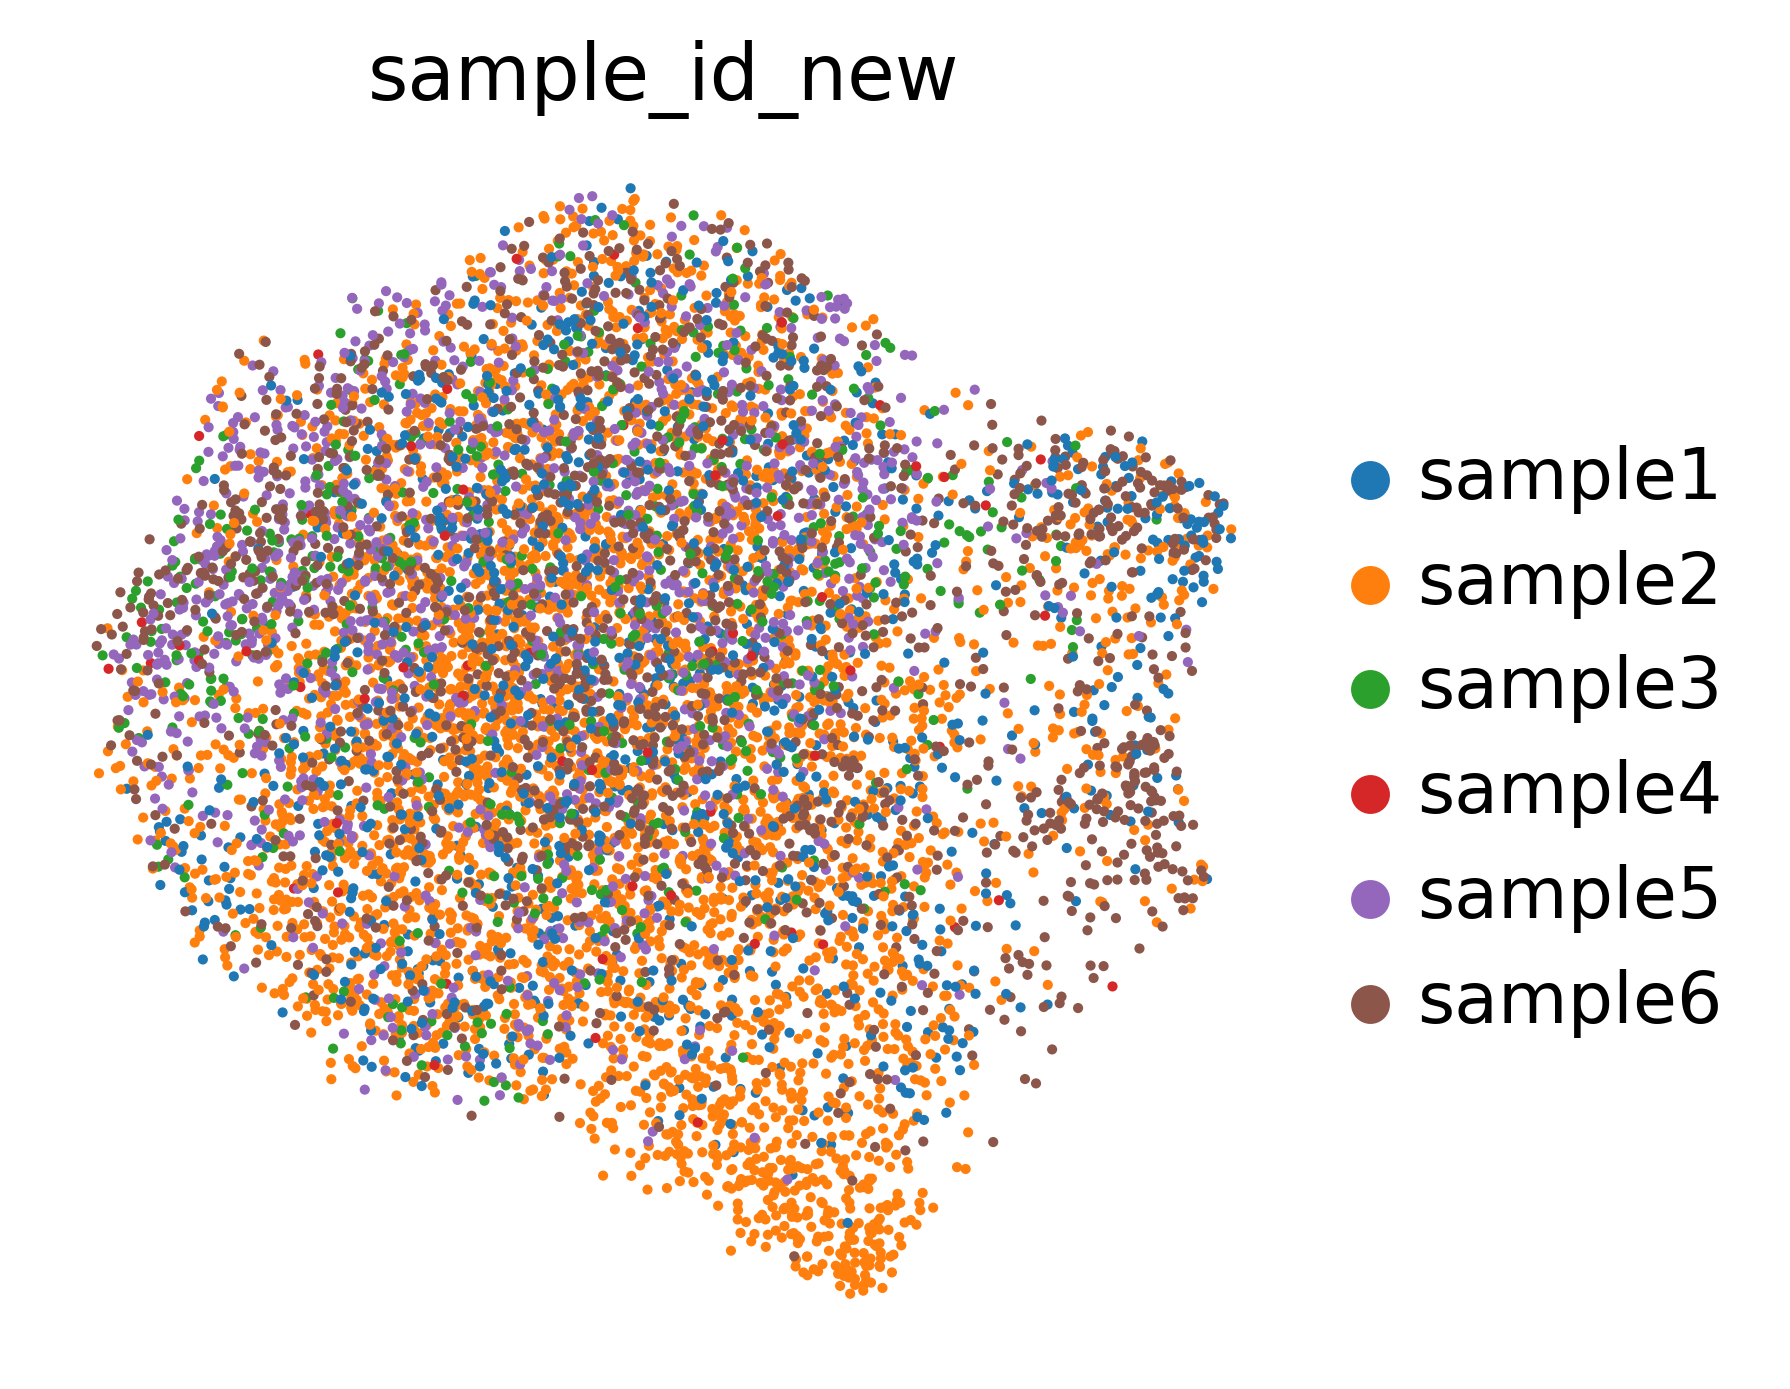

In [ ]:
# Plot UMAP 
sc.pl.embedding(
    adata,
    basis="X_umap",
    color="sample_id_new",
    sort_order=False,
    frameon=False,
)

## Plot UMAP from trVAE embedding (10 features)

In [29]:
adata_fibers_trvae_10 = sc.read_h5ad("integrated_480_5000/adata_integrated_480_5000_fibers_trvae_filtered.h5ad")
adata_fibers_trvae_10

AnnData object with n_obs × n_vars = 8967 × 4576
    obs: 'cell_ID', 'fov_labels', 'shapeSize', 'sample_id', 'condition', 'muscle_type', 'sample_id_new', 'cell_type_annotation', 'cell_type_annotation_clean', 'sample_condition', 'unique_cell_ID', 'spatial_niches', 'spatial_niches_number', 'spatial_niches_fibers', 'spatial_niches_fibers_number', 'cell_type_annotation_fiber_subtypes', 'CD8_in_neighborhood_200_480', 'CD8_in_neighborhood_200_5000', 'CD8_in_neighborhood_200_mean', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'sample_id_new_colors', 'umap'
    obsm: 'X_pca', 'X_trVAE', 'X_u

In [30]:
# Calculate 15 nearest neighbors in X_trVAE space
sc.pp.neighbors(adata_fibers_trvae_10, use_rep="X_trVAE", random_state=1)
# Calculate UMAP using nn's
sc.tl.umap(adata_fibers_trvae_10)

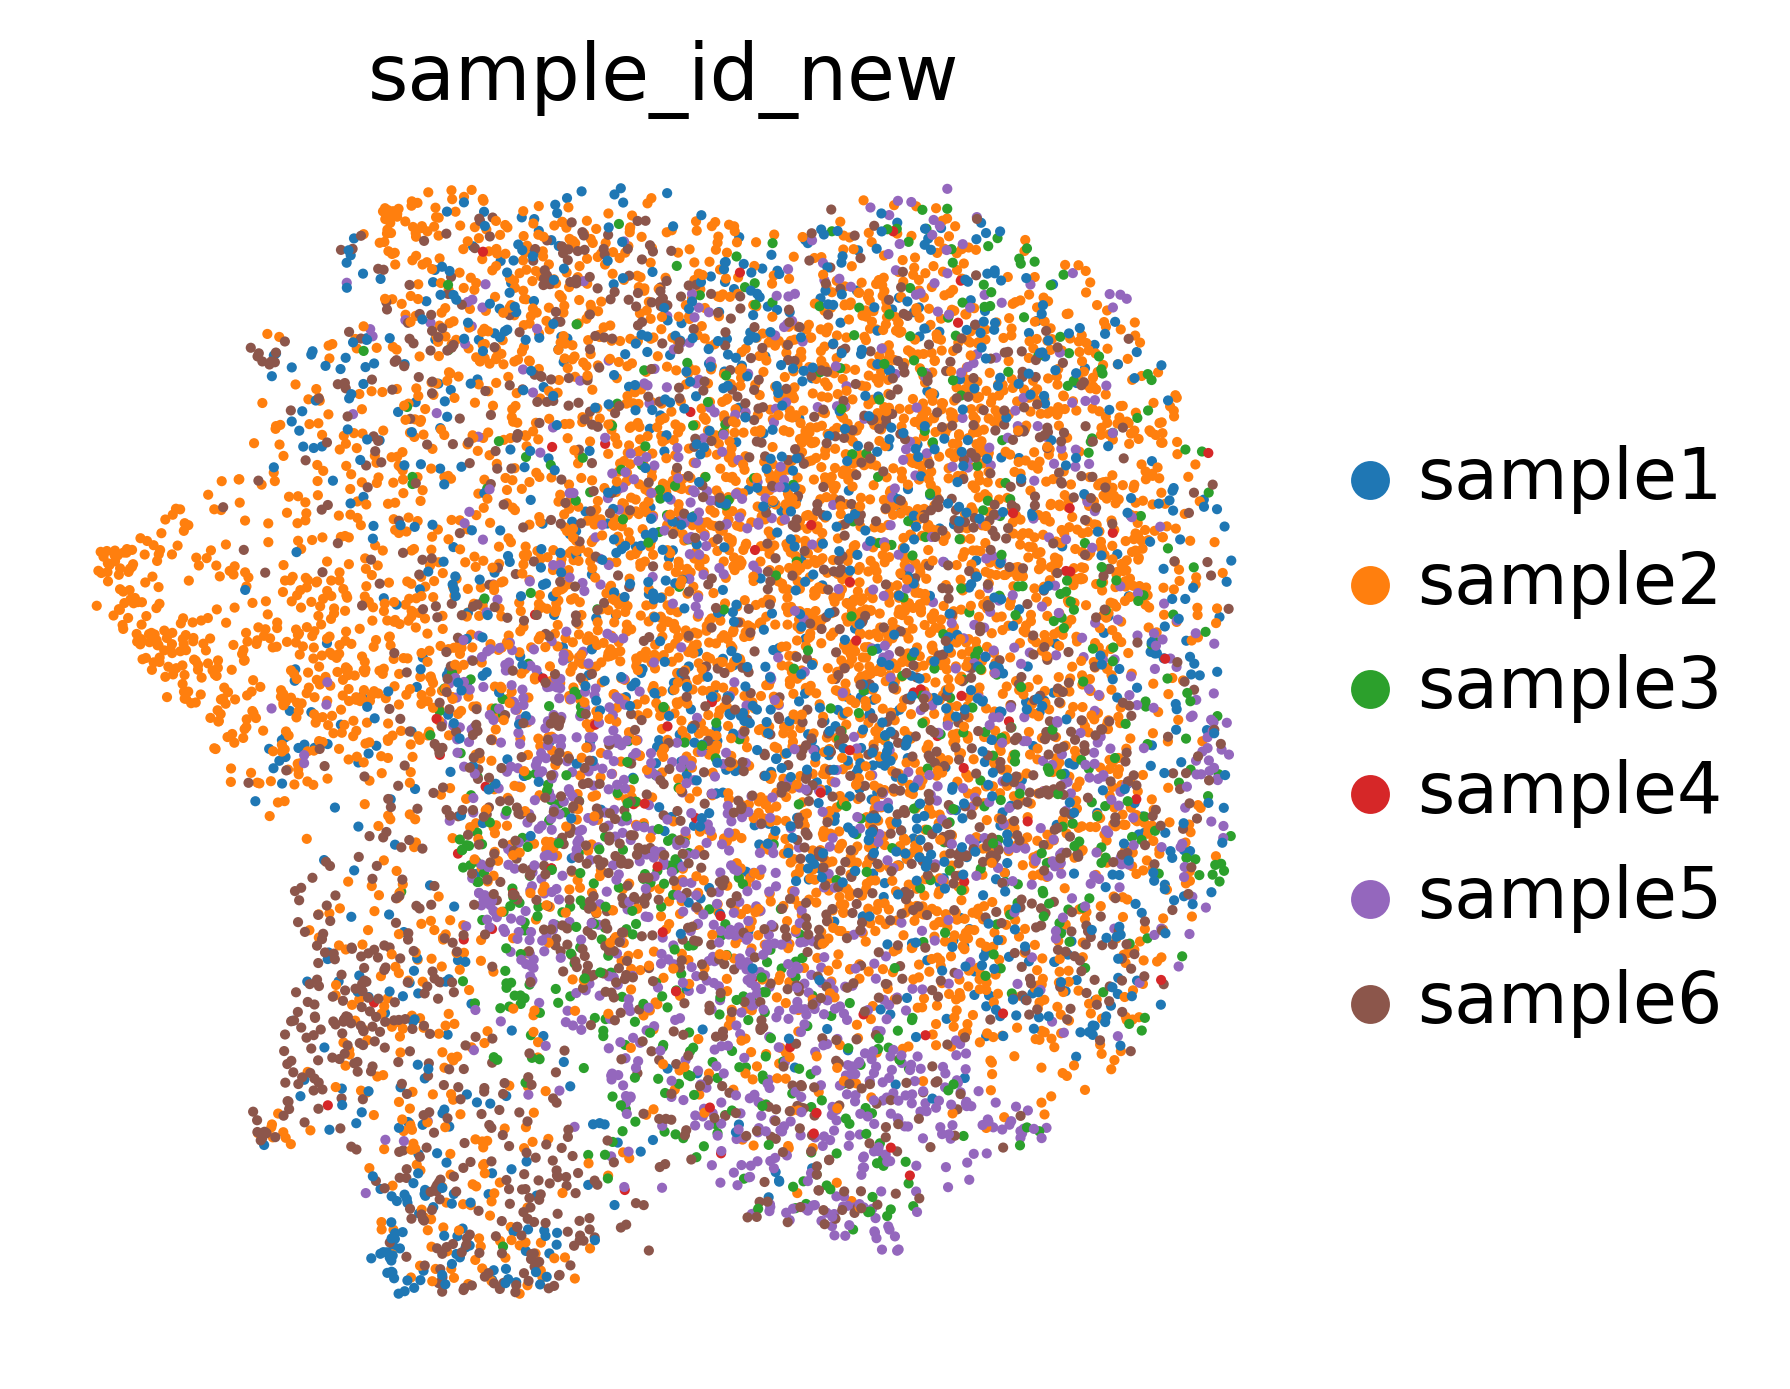

In [31]:
# Plot UMAP
sc.pl.embedding(
    adata_fibers_trvae_10,
    basis="X_umap",
    color="sample_id_new",
    sort_order=False,
    frameon=False,
)

There is no clear difference in the trVAE embedding UMAP with 10 vs 20 trVAE features. I continued with the default 10 features (also used in the full fibers+nuclei 480 and 5000 datasets.)